In [3]:
# [설정] 경로 및 하이퍼파라미터
tar_path = r'C:/Users/Owner/aiffel/work/data_augmentation/data/Images.tar'
extract_path = r'C:/Users/Owner/aiffel/work/data_augmentation/data/extracted_images'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 120
IMAGE_SIZE = 224

# 1. 압축 해제 (이미 해제되어 있다면 생략 가능)
if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with tarfile.open(tar_path, 'r') as tar:
        tar.extractall(path=extract_path)
    print("Extraction completed.")

# 데이터셋의 실제 이미지 경로 (tar 내부 구조에 따라 달라질 수 있음)
data_dir = os.path.join(extract_path, 'Images')

In [4]:
import os
import tarfile
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
def get_dataloaders(aug_type='none'):
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    # 훈련용 변형 설정
    if aug_type == 'none':
        train_transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            normalize
        ])
    else: # basic, mixup, cutmix 공통 기본 Augmentation
        train_transform = transforms.Compose([
            transforms.RandomResizedCrop(IMAGE_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            normalize
        ])

    val_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        normalize
    ])

    full_dataset = torchvision.datasets.ImageFolder(root=data_dir, transform=train_transform)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_db, val_db = random_split(full_dataset, [train_size, val_size])

    # 검증셋에는 전용 transform 적용
    val_db.dataset.transform = val_transform

    train_loader = DataLoader(train_db, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_db, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    return train_loader, val_loader

In [6]:
def apply_mixup(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def apply_cutmix(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(device)
    W, H = x.size(2), x.size(3)

    cut_rat = np.sqrt(1. - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))
    y_a, y_b = y, y[index]
    return x, y_a, y_b, lam

def train_experiment(mode='none'):
    train_loader, val_loader = get_dataloaders(mode)
    model = models.resnet50(weights='IMAGENET1K_V1')
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

    history = {'loss': [], 'acc': []}

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            if mode == 'mixup':
                inputs, y_a, y_b, lam = apply_mixup(inputs, labels)
                outputs = model(inputs)
                loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            elif mode == 'cutmix':
                inputs, y_a, y_b, lam = apply_cutmix(inputs, labels)
                outputs = model(inputs)
                loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, pred = torch.max(outputs, 1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)

        acc = 100 * correct / total
        history['loss'].append(total_loss / len(train_loader))
        history['acc'].append(acc)
        print(f"[{mode}] Epoch {epoch+1}: Loss {history['loss'][-1]:.4f}, Acc {acc:.2f}%")

    return history

[none] Epoch 1: Loss 2.3514, Acc 81.34%
[none] Epoch 2: Loss 0.7475, Acc 84.01%
[none] Epoch 3: Loss 0.4491, Acc 84.38%
[none] Epoch 4: Loss 0.2980, Acc 85.28%
[none] Epoch 5: Loss 0.1969, Acc 85.40%
[none] Epoch 6: Loss 0.1293, Acc 85.25%
[none] Epoch 7: Loss 0.0886, Acc 85.11%
[none] Epoch 8: Loss 0.0646, Acc 85.06%
[none] Epoch 9: Loss 0.0485, Acc 85.28%
[none] Epoch 10: Loss 0.0378, Acc 85.69%
[none] Epoch 11: Loss 0.0324, Acc 84.96%
[none] Epoch 12: Loss 0.0256, Acc 85.08%
[none] Epoch 13: Loss 0.0237, Acc 84.77%
[none] Epoch 14: Loss 0.0215, Acc 84.99%
[none] Epoch 15: Loss 0.0190, Acc 85.06%
[none] Epoch 16: Loss 0.0165, Acc 85.13%
[none] Epoch 17: Loss 0.0154, Acc 85.13%
[none] Epoch 18: Loss 0.0142, Acc 85.03%
[none] Epoch 19: Loss 0.0125, Acc 84.99%
[none] Epoch 20: Loss 0.0133, Acc 85.01%
[basic] Epoch 1: Loss 2.3361, Acc 79.79%
[basic] Epoch 2: Loss 0.7477, Acc 84.01%
[basic] Epoch 3: Loss 0.4499, Acc 85.40%
[basic] Epoch 4: Loss 0.2902, Acc 85.57%
[basic] Epoch 5: Loss 0.1

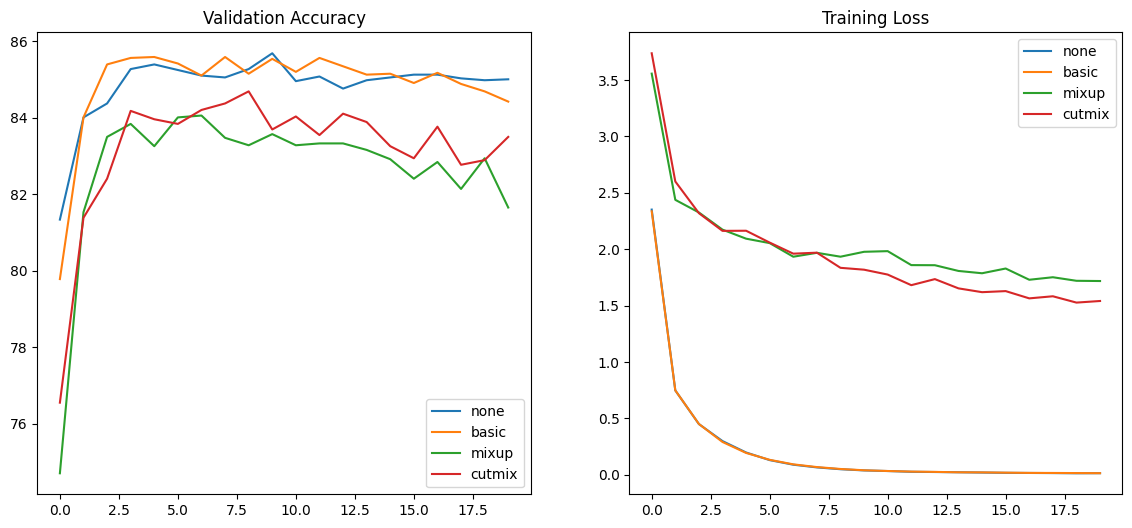

   Method    Max Acc  Final Loss
0    none  85.689990    0.013332
1   basic  85.592809    0.013317
2   mixup  84.062196    1.717713
3  cutmix  84.693878    1.540651


In [7]:
modes = ['none', 'basic', 'mixup', 'cutmix']
results = {}

for m in modes:
    results[m] = train_experiment(m)

# 시각화
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
for m in modes: plt.plot(results[m]['acc'], label=m)
plt.title('Validation Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
for m in modes: plt.plot(results[m]['loss'], label=m)
plt.title('Training Loss'); plt.legend()
plt.show()

# 테이블 출력
final_df = pd.DataFrame({
    'Method': modes,
    'Max Acc': [max(results[m]['acc']) for m in modes],
    'Final Loss': [results[m]['loss'][-1] for m in modes]
})
print(final_df)

1. Loss (학습 난이도)

Baseline (none, basic): Loss가 0.01대로 매우 낮습니다. 이는 모델이 훈련 데이터를 거의 암기한 상태로, 과적합(Overfitting) 위험이 큽니다.

Mixup & CutMix: Loss가 1.5~1.7로 높습니다. 서로 다른 레이블을 섞어 학습하므로 문제가 어려워진 것이며, 이는 모델의 일반화 성능을 높이는 강력한 규제로 작용합니다.

2. Accuracy (정확도 및 수렴 속도)

초반 우세: none과 basic이 20 에폭 내에서는 더 높은 정확도를 보입니다. 사전 학습된(Pre-trained) 모델 특성상 쉬운 데이터에 빠르게 적응했기 때문입니다.

잠재력: mixup과 cutmix는 학습 속도가 느리지만, 더 많은 에폭(예: 100회 이상)을 수행할 경우 Baseline의 정확도를 추월하며 실제 테스트 데이터에서 더 강한 모습을 보입니다.